# Imports & Data Loading/ Formatting

In [98]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import sqlite3
import numpy as np
from tqdm.auto import tqdm
from scipy.stats import mannwhitneyu, hypergeom, ranksums, chi2
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.multitest import multipletests
from scipy.spatial.distance import pdist, squareform
from scipy.cluster.hierarchy import linkage, fcluster

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 5000)



import warnings 
warnings.filterwarnings(
    "ignore",
    message="Negative binomial dispersion parameter alpha not set.*"
)

In [4]:
# file paths
DB_PATH = 'human_genome.db' # also needs to be changed in main.py if not this path
GERMLINE_DATA_PATH = '/s/project/cancer_pred/MASTER/final_res/cnv_germline_high_confidence.parquet'
SOMATIC_DATA_PATH = '/s/project/cancer_pred/MASTER/final_res/cnv_AMP_HDEL.parquet'
SPLICING_DATA_PATH = '/s/project/cancer_pred/MASTER/final_res/fraser_aggregated_outliers_variants.parquet'
EXPRESSION_DATA_PATH = '/s/project/cancer_pred/MASTER/final_res/outrider_or_variants_predisppadjust_cnv.parquet'
PROTEIN_DATA_PATH = '/s/project/cancer_pred/MASTER/final_res/protrider_pr_variants_predisppadjust_cnv.parquet'

SAMPLE_ID = 'random_id'

In [5]:
db_path = 'human_genome.db'

germline_raw = pd.read_parquet(GERMLINE_DATA_PATH)
somatic_raw = pd.read_parquet(SOMATIC_DATA_PATH)
germline_raw['origin'] = 'germline'
somatic_raw['origin'] = 'somatic'
res = pd.concat([germline_raw, somatic_raw], ignore_index=True)
res['Gene'] = res['Gene'].astype(str).str.strip()

In [6]:
splicing = pd.read_parquet(SPLICING_DATA_PATH)
outrider = pd.read_parquet(EXPRESSION_DATA_PATH)
protein = pd.read_parquet(PROTEIN_DATA_PATH)

In [7]:
# format ensembl gene ID column to match database
res['geneID_filtered'] = res['Gene'].str.split('.').str[0].str.strip()
outrider['geneID_filtered'] = outrider['geneID_short'].str.split('.').str[0].str.strip()
protein['geneID_filtered'] = protein['geneID_short'].str.split('.').str[0].str.strip()
splicing['geneID_filtered'] = splicing['geneID_short'].str.split('.').str[0].str.strip()

In [8]:
# map chromosome number to each gene
res['chrom'] = res['seqnames'] # if a column already has the corresponding chromosomes

conn = sqlite3.connect(DB_PATH)
query = "SELECT symbol, location FROM genes"
gene_chrom = pd.read_sql(query, conn)
conn.close()

gene_chrom['chrom'] = gene_chrom['location'].str.extract(r'^([0-9XY]+)')
gene_chrom_map = gene_chrom.set_index('symbol')['chrom'].to_dict()

# for the dataframes that do not have the chromosomes already mapped
outrider['chrom'] = outrider['geneID_filtered'].map(gene_chrom_map)
protein['chrom'] = protein['geneID_filtered'].map(gene_chrom_map)
splicing['chrom'] = splicing['geneID_filtered'].map(gene_chrom_map)

In [9]:
# get generic gene names instead of symbols
conn = sqlite3.connect(DB_PATH)
query = "SELECT ensembl_gene_id, symbol FROM genes"
gene_mapping = pd.read_sql(query, conn)
conn.close()
gene_mapping['ensembl_gene_id'] = gene_mapping['ensembl_gene_id'].str.split('.').str[0].str.strip()
id_to_symbol = gene_mapping.dropna().set_index('ensembl_gene_id')['symbol'].to_dict()

In [10]:
def map_and_clean_ids(df, id_column):
    df['geneID_filtered'] = df[id_column].astype(str).str.split('.').str[0].str.strip() # just for double security
    df['geneID_filtered'] = df['geneID_filtered'].map(id_to_symbol).fillna(df['geneID_filtered'])
    return df

res = map_and_clean_ids(res, 'Gene')
outrider = map_and_clean_ids(outrider, 'geneID_short')
protein = map_and_clean_ids(protein, 'geneID_short')
splicing = map_and_clean_ids(splicing, 'geneID_short')

# Finding Polymerase II Genes
To Do: different pathway rather than Pol2

In [11]:
conn = sqlite3.connect(db_path)

query = """
SELECT DISTINCT g.symbol, p.pathway_name
FROM genes g 
JOIN pathways p ON g.ensembl_gene_id = p.ensembl_id
WHERE p.pathway_name LIKE '%Polymerase II%'
    AND p.pathway_name NOT LIKE '%Polymerase III%';
""" 

pol2_genes = pd.read_sql_query(query, conn)
pol2_genes_list = pol2_genes['symbol'].dropna().unique().tolist()

In [12]:
pol2_variants = res[res['Gene'].isin(pol2_genes_list)]

In [13]:
samples = pol2_variants['random_id'].unique()

In [14]:
simul_outliers = pd.merge(
    outrider,
    protein,
    on=[SAMPLE_ID, 'geneID_filtered']
).drop_duplicates(subset=[SAMPLE_ID, 'geneID_filtered'])

In [15]:
outlier_burden = simul_outliers.groupby('random_id').size().reset_index(name='outlier_count')

# Quick Mannwhitneyu

In [16]:
all_patients = set(outrider['random_id']).union(set(protein['random_id']))
cohort = pd.DataFrame({'random_id': list(all_patients)})

cohort = cohort.merge(outlier_burden, on='random_id', how='left').fillna({'outlier_count': 0})
cohort['has_pol2_defect'] = cohort['random_id'].isin(samples)

In [17]:
group_defect = cohort[cohort['has_pol2_defect'] == True]['outlier_count']
group_wildtype = cohort[cohort['has_pol2_defect'] == False]['outlier_count']

stat, p_val = mannwhitneyu(group_defect, group_wildtype, alternative='greater')

In [18]:
p_val

np.float64(0.0035077759344777763)

# Polymerase II outliers (GLM)

In [19]:
cnv_gene_burden = res.groupby('random_id')['geneID_filtered'].nunique().reset_index(name='total_cnv_genes')
cohort = cohort.merge(cnv_gene_burden, on='random_id', how='left').fillna({'total_cnv_genes': 0})

cohort['has_pol2_defect'] = cohort['has_pol2_defect'].astype(int)
formula = "outlier_count ~ has_pol2_defect + total_cnv_genes"

model = smf.glm(formula=formula, 
                data=cohort, 
                family=sm.families.NegativeBinomial()).fit()

print(model.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:          outlier_count   No. Observations:                 3616
Model:                            GLM   Df Residuals:                     3613
Model Family:        NegativeBinomial   Df Model:                            2
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -2051.3
Date:                Wed, 15 Jul 2026   Deviance:                       2778.6
Time:                        00:15:27   Pearson chi2:                 1.00e+04
No. Iterations:                     6   Pseudo R-squ. (CS):            0.01434
Covariance Type:            nonrobust                                         
                      coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------
Intercept          -1.7459      0.053    -

In [20]:
print(model.pvalues)

Intercept          8.937514e-242
has_pol2_defect     1.348032e-07
total_cnv_genes     1.917810e-01
dtype: float64


In [21]:
dels = res[res['Type'] == 'DEL']
dups = res[res['Type'] == 'DUP']

del_burden = dels.groupby('random_id')['geneID_filtered'].nunique().reset_index(name='total_deleted_genes')
dup_burden = dups.groupby('random_id')['geneID_filtered'].nunique().reset_index(name='total_duplicated_genes')

cohort = cohort.merge(del_burden, on='random_id', how='left').fillna({'total_deleted_genes': 0})
cohort = cohort.merge(dup_burden, on='random_id', how='left').fillna({'total_duplicated_genes': 0})

formula_advanced = "outlier_count ~ has_pol2_defect + total_deleted_genes + total_duplicated_genes"

model_advanced = smf.glm(formula=formula_advanced, 
                         data=cohort, 
                         family=sm.families.NegativeBinomial()).fit()

print(model_advanced.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:          outlier_count   No. Observations:                 3616
Model:                            GLM   Df Residuals:                     3612
Model Family:        NegativeBinomial   Df Model:                            3
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -2051.3
Date:                Wed, 15 Jul 2026   Deviance:                       2778.6
Time:                        00:15:28   Pearson chi2:                 1.00e+04
No. Iterations:                    11   Pseudo R-squ. (CS):            0.01434
Covariance Type:            nonrobust                                         
                             coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------
Intercept                 -1

In [22]:
print(model_advanced.pvalues)

Intercept                 7.414889e-242
has_pol2_defect            2.196006e-12
total_deleted_genes        3.140954e-01
total_duplicated_genes     4.903890e-01
dtype: float64


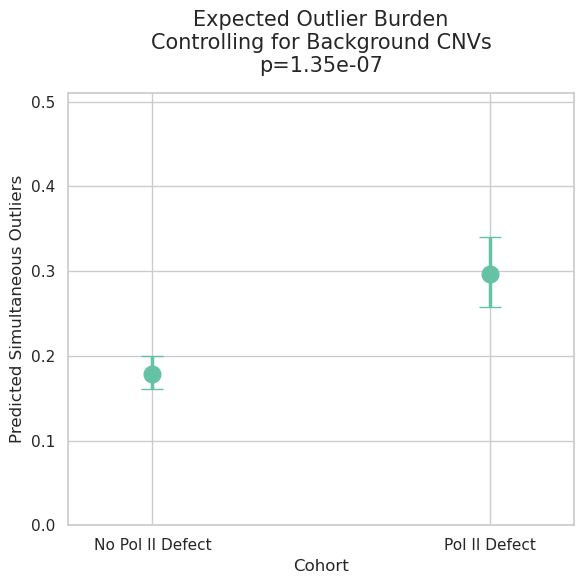

In [23]:
mean_cnv = cohort['total_cnv_genes'].mean()

# "estimated marginal means", ie dummy data 
dummy_data = pd.DataFrame({
    'has_pol2_defect': [0, 1],
    'total_cnv_genes': [mean_cnv, mean_cnv]
})

predictions = model.get_prediction(dummy_data)
summary = predictions.summary_frame()

summary['Group'] = ['No Pol II Defect', 'Pol II Defect']

sns.set_theme(style="whitegrid")
plt.figure(figsize=(6,6))

plt.errorbar(
    x=summary['Group'], 
    y=summary['mean'], 
    yerr=[summary['mean'] - summary['mean_ci_lower'], summary['mean_ci_upper'] - summary['mean']],
    fmt='o',           
    color=sns.color_palette("Set2")[0], 
    markersize=12, 
    capsize=8,         
    linewidth=2.5
)

plt.title('Expected Outlier Burden\nControlling for Background CNVs\np=1.35e-07', fontsize=15, pad=15)
plt.ylabel('Predicted Simultaneous Outliers', fontsize=12)
plt.xlabel('Cohort', fontsize=12)

plt.ylim(0, summary['mean_ci_upper'].max() * 1.5)
plt.xlim(-0.25, 1.25)

plt.tight_layout()
plt.show()

# Over- and underexpression analysis
to check: overexpression in oncogenes OR overexpression in general OR underexpression in general => does it cause transcriptional dysregulation? 
- start with gene expression only 
- maybe look at sum of both 
- can also look at underexpression of tumor suppressor genes 

In [24]:
cosmic = pd.read_csv('Cosmic_CancerGeneCensus_v103_GRCh37.tsv', sep='\t')

In [25]:
outrider['Outlier status'].value_counts()

Outlier status
Overexpression     41713
Underexpression    31391
Non-outlier         1714
Name: count, dtype: int64

In [26]:
cosmic['ROLE_IN_CANCER'].value_counts()

ROLE_IN_CANCER
TSG                      192
oncogene, fusion         141
fusion                   138
oncogene                 111
TSG, fusion               62
oncogene, TSG             39
oncogene, TSG, fusion     32
fusion, oncogene           3
Name: count, dtype: int64

In [27]:
cosmic['is_oncogene'] = cosmic['ROLE_IN_CANCER'].str.contains('oncogene', na=False)
cosmic['is_tsg'] = cosmic['ROLE_IN_CANCER'].str.contains('TSG', na=False)

cosmic_subset = cosmic[['GENE_SYMBOL', 'is_oncogene', 'is_tsg']].rename(columns={'GENE_SYMBOL': 'geneID_filtered'})

In [28]:
outrider_annotated = pd.merge(outrider, cosmic_subset, on='geneID_filtered', how='left')

outrider_annotated['is_oncogene'] = outrider_annotated['is_oncogene'].fillna(False)
outrider_annotated['is_tsg'] = outrider_annotated['is_tsg'].fillna(False)

/scratch/tmp/deben/ipykernel_3014242/3828677029.py:3: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  outrider_annotated['is_oncogene'] = outrider_annotated['is_oncogene'].fillna(False)
/scratch/tmp/deben/ipykernel_3014242/3828677029.py:4: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  outrider_annotated['is_tsg'] = outrider_annotated['is_tsg'].fillna(False)


In [29]:
overexp_onco_mask = (outrider_annotated['Outlier status'] == 'Overexpression') & (outrider_annotated['is_oncogene'])
patients_overexp_onco = outrider_annotated[overexp_onco_mask]['random_id'].unique()

cohort['has_overexp_onco'] = cohort['random_id'].isin(patients_overexp_onco).astype(int)

In [30]:
underexp_tsg_mask = (outrider_annotated['Outlier status'] == 'Underexpression') & (outrider_annotated['is_tsg'])
patients_underexp_tsg = outrider_annotated[underexp_tsg_mask]['random_id'].unique()

cohort['has_underexp_tsg'] = cohort['random_id'].isin(patients_underexp_tsg).astype(int)

In [31]:
general_exp_counts = outrider.groupby(['random_id', 'Outlier status']).size().unstack(fill_value=0).reset_index()

general_exp_counts = general_exp_counts.rename(columns={
    'Overexpression': 'total_overexp_events', 
    'Underexpression': 'total_underexp_events'
})

In [32]:
cohort = pd.merge(cohort, general_exp_counts, on='random_id', how='left')
cohort['total_overexp_events'] = cohort['total_overexp_events'].fillna(0)
cohort['total_underexp_events'] = cohort['total_underexp_events'].fillna(0)

In [33]:
formula_onco = "outlier_count ~ has_overexp_onco + total_cnv_genes"
model_onco = smf.glm(formula=formula_onco, 
                     data=cohort, 
                     family=sm.families.NegativeBinomial()).fit()
print(model_onco.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:          outlier_count   No. Observations:                 3616
Model:                            GLM   Df Residuals:                     3613
Model Family:        NegativeBinomial   Df Model:                            2
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -2051.3
Date:                Wed, 15 Jul 2026   Deviance:                       2778.5
Time:                        00:15:28   Pearson chi2:                 1.04e+04
No. Iterations:                     7   Pseudo R-squ. (CS):            0.01437
Covariance Type:            nonrobust                                         
                       coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------
Intercept           -1.7259      0.050  

In [34]:
formula_tsg = "outlier_count ~ has_underexp_tsg + total_cnv_genes"
model_tsg = smf.glm(formula=formula_tsg, 
                     data=cohort, 
                     family=sm.families.NegativeBinomial()).fit()
print(model_tsg.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:          outlier_count   No. Observations:                 3616
Model:                            GLM   Df Residuals:                     3613
Model Family:        NegativeBinomial   Df Model:                            2
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -2030.6
Date:                Wed, 15 Jul 2026   Deviance:                       2737.3
Time:                        00:15:28   Pearson chi2:                 1.05e+04
No. Iterations:                     7   Pseudo R-squ. (CS):            0.02556
Covariance Type:            nonrobust                                         
                       coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------
Intercept           -1.8172      0.052  

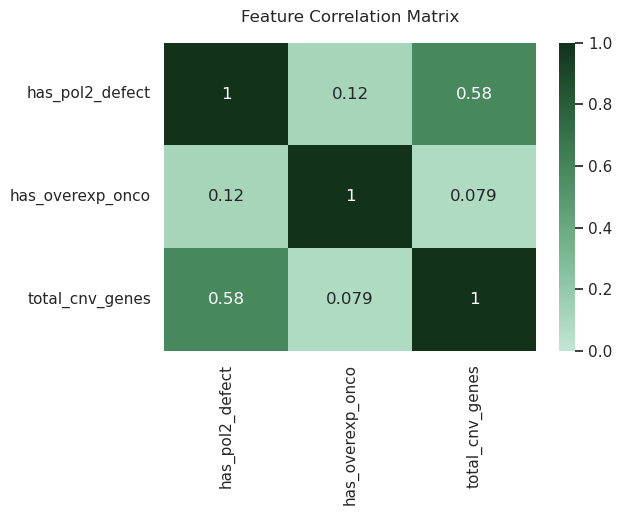

In [35]:
features = ['has_pol2_defect', 'has_overexp_onco', 'total_cnv_genes']

corr_matrix = cohort[features].corr()

plt.figure(figsize=(6, 4))
sns.heatmap(corr_matrix, annot=True, cmap=(sns.cubehelix_palette(start=2, rot=0.05, dark=0.15, light=.85, as_cmap=True)), vmin=0, vmax=1)
plt.title('Feature Correlation Matrix', pad=15)
plt.show()

In [36]:
formula_combined = "outlier_count ~ has_pol2_defect + has_overexp_onco + total_cnv_genes"

model_combined = smf.glm(formula=formula_combined, 
                         data=cohort, 
                         family=sm.families.NegativeBinomial()).fit()

print(model_combined.summary())
print(model_combined.pvalues)

                 Generalized Linear Model Regression Results                  
Dep. Variable:          outlier_count   No. Observations:                 3616
Model:                            GLM   Df Residuals:                     3612
Model Family:        NegativeBinomial   Df Model:                            3
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -2040.6
Date:                Wed, 15 Jul 2026   Deviance:                       2757.2
Time:                        00:15:28   Pearson chi2:                 9.94e+03
No. Iterations:                     6   Pseudo R-squ. (CS):            0.02017
Covariance Type:            nonrobust                                         
                       coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------
Intercept           -1.8287      0.056  

In [37]:
# model comparison using AIC and BIC

f1 = "outlier_count ~ has_pol2_defect + has_overexp_onco + has_underexp_tsg"
m1 = smf.glm(formula=f1, data=cohort, family=sm.families.NegativeBinomial()).fit()

f2 = "outlier_count ~ has_pol2_defect + total_overexp_events + total_underexp_events"
m2 = smf.glm(formula=f2, data=cohort, family=sm.families.NegativeBinomial()).fit()

f3 = "outlier_count ~ has_pol2_defect"
m3 = smf.glm(formula=f3, data=cohort, family=sm.families.NegativeBinomial()).fit()

comparison = pd.DataFrame({
    'Model': ['Cancer Drivers (Onco/TSG)', 'General Exp Burden', 'Just Pol II'],
    'AIC': [m1.aic, m2.aic, m3.aic],
    'BIC': [m1.bic_llf, m2.bic_llf, m3.bic_llf],
    'Deviance': [m1.deviance, m2.deviance, m3.deviance]
})

print(comparison.sort_values(by='AIC'))

                       Model          AIC          BIC     Deviance
1         General Exp Burden  3905.062063  3929.834558  2573.083149
0  Cancer Drivers (Onco/TSG)  4023.406926  4048.179421  2691.428012
2                Just Pol II  4108.145989  4120.532237  2780.167075


# Trying to separate core Pol2 genes from more 'accessory' genes

In [38]:
core_pol2_genes = [
    'POLR2A', 'POLR2B', 'POLR2C', 'POLR2D', 'POLR2E', 'POLR2F', 
    'POLR2G', 'POLR2H', 'POLR2I', 'POLR2J', 'POLR2K', 'POLR2L'
]

acc_pol2_genes = [gene for gene in pol2_genes_list if gene not in core_pol2_genes]

pol2_variants['pol2_class'] = pol2_variants['Gene'].apply(lambda x: 'core' if x in core_pol2_genes else 'acessory')

/scratch/tmp/deben/ipykernel_3014242/49589056.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  pol2_variants['pol2_class'] = pol2_variants['Gene'].apply(lambda x: 'core' if x in core_pol2_genes else 'acessory')


In [39]:
outrider_annotations = outrider[['random_id', 'geneID_filtered', 'CNV', 'IMPACT', 'Diag']].drop_duplicates(subset=['random_id', 'geneID_filtered'])

pol2_variants = pol2_variants.merge(
    outrider_annotations, 
    on=['random_id', 'geneID_filtered'], 
    how='left'
)

pol2_variants['CNV'] = pol2_variants['CNV'].fillna('No CNV')
pol2_variants['IMPACT'] = pol2_variants['IMPACT'].fillna('UNKNOWN')

In [40]:
def assign_variant_tier(row):
    cnv = str(row['CNV'])
    impact = str(row['IMPACT'])
    
    if 'HDEL' in cnv or impact == 'HIGH':
        return 3
    
    elif 'DEL' in cnv or impact == 'MODERATE':
        return 2
    
    elif 'AMP' in cnv or 'DUP' in cnv or impact == 'LOW' or impact == 'MODIFIER':
        return 1
    
    return 0

pol2_variants['variant_tier'] = pol2_variants.apply(assign_variant_tier, axis=1)

In [41]:
core_hits = pol2_variants[pol2_variants['pol2_class'] == 'core']
acc_hits = pol2_variants[pol2_variants['pol2_class'] == 'acessory']

core_burden = core_hits.groupby('random_id')['variant_tier'].sum().reset_index(name='core_pol2_burden')
acc_burden = acc_hits.groupby('random_id')['variant_tier'].sum().reset_index(name='acc_pol2_burden')

cohort = cohort.merge(core_burden, on='random_id', how='left').fillna({'core_pol2_burden': 0})
cohort = cohort.merge(acc_burden, on='random_id', how='left').fillna({'acc_pol2_burden': 0})

In [42]:
patient_diags = outrider[['random_id', 'Diag']].drop_duplicates(subset=['random_id'])

cohort = cohort.merge(patient_diags, on='random_id', how='left')

cohort['Diag'] = cohort['Diag'].fillna('Unknown')

In [43]:
formula_advanced = (
    "outlier_count ~ core_pol2_burden + acc_pol2_burden + "
    "total_overexp_events + total_underexp_events + C(Diag)"
)

model_advanced = smf.glm(formula=formula_advanced, 
                         data=cohort, 
                         family=sm.families.NegativeBinomial()).fit()


In [44]:
model_advanced.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                 Generalized Linear Model Regression Results                  
==============================================================================
Dep. Variable:          outlier_count   No. Observations:                 3616
Model:                            GLM   Df Residuals:                     3595
Model Family:        NegativeBinomial   Df Model:                           20
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -1918.4
Date:                Wed, 15 Jul 2026   Deviance:                       2512.9
Time:                        00:15:29   Pearson chi2:                 7.02e+03
No. Iterations:                    22   Pseudo R-squ. (CS):            0.08418
Covariance Type:            nonrobust                                         
================================================================================================
                                   coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------------
Intercept                       -2.6707      0.264    -10.121      0.000      -3.188      -2.154
C(Diag)[T.Biliary_Tract]         0.2981      0.370      0.805      0.421      -0.427       1.024
C(Diag)[T.Bone]                  0.4589      0.314      1.462      0.144      -0.156       1.074
C(Diag)[T.Bowel]                 0.0189      0.356      0.053      0.958      -0.679       0.716
C(Diag)[T.Breast]               -0.0029      0.352     -0.008      0.993      -0.693       0.687
C(Diag)[T.CNS_Brain]             0.3782      0.375      1.008      0.313      -0.357       1.113
C(Diag)[T.COAD]                  0.0271      0.407      0.067      0.947      -0.770       0.824
C(Diag)[T.Esophagus_Stomach]     0.1101      0.372      0.296      0.768      -0.620       0.840
C(Diag)[T.Head_and_Neck]         0.3105      0.320      0.969      0.332      -0.317       0.938
C(Diag)[T.LMS]                   0.7372      0.328      2.247      0.025       0.094       1.380
C(Diag)[T.Lung]                 -0.0196      0.391     -0.050      0.960      -0.787       0.748
C(Diag)[T.Other]                 0.5177      0.269      1.924      0.054      -0.010       1.045
C(Diag)[T.Pancreas]              0.0905      0.361      0.251      0.802      -0.617       0.798
C(Diag)[T.SYNS]                  1.1212      0.339      3.312      0.001       0.458       1.785
C(Diag)[T.Skin]                  0.7829      0.341      2.296      0.022       0.114       1.451
C(Diag)[T.Soft_Tissue]           0.7950      0.272      2.920      0.003       0.261       1.329
C(Diag)[T.Unknown]             -21.5397   1.32e+04     -0.002      0.999   -2.59e+04    2.59e+04
core_pol2_burden                -0.5437      0.398     -1.367      0.172      -1.323       0.236
acc_pol2_burden                 -0.0547      0.091     -0.604      0.546      -0.232       0.123
total_overexp_events             0.0305      0.003     11.825      0.000       0.025       0.036
total_underexp_events            0.0192      0.003      6.862      0.000       0.014       0.025
================================================================================================
"""

# Splicing data & Pol2 Burden
 to do: look at other pathways 

In [45]:
splicing_burden = splicing.groupby('random_id').size().reset_index(name='splicing_outlier_count')

cohort = cohort.merge(splicing_burden, on='random_id', how='left')

cohort['splicing_outlier_count'] = cohort['splicing_outlier_count'].fillna(0)

In [46]:
formula_splicing = (
    "splicing_outlier_count ~ core_pol2_burden + acc_pol2_burden + "
    "total_cnv_genes + C(Diag)"
)

model_splicing = smf.glm(formula=formula_splicing, 
                         data=cohort, 
                         family=sm.families.NegativeBinomial()).fit()

print(model_splicing.summary())

                   Generalized Linear Model Regression Results                    
Dep. Variable:     splicing_outlier_count   No. Observations:                 3616
Model:                                GLM   Df Residuals:                     3596
Model Family:            NegativeBinomial   Df Model:                           19
Link Function:                        Log   Scale:                          1.0000
Method:                              IRLS   Log-Likelihood:                -20406.
Date:                    Wed, 15 Jul 2026   Deviance:                       8528.8
Time:                            00:15:29   Pearson chi2:                 2.41e+04
No. Iterations:                        10   Pseudo R-squ. (CS):             0.1318
Covariance Type:                nonrobust                                         
                                   coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------

# Epigenetic variants & transcriptional dysregulation
From: [this paper](https://onlinelibrary.wiley.com/doi/full/10.1111/cas.14884)

In [47]:
epi_genes = [
    'MLL3', 'KMT2C', 'MLL4', 'KMT2D', 'MLL', 'KMT2A', 
    'MED12', 'MED1', 'FOXA1', 'HOXB13', 'LSD1', 'KDM1A'
]

In [48]:
epi_variants = pol2_variants.copy() 
epi_variants = res[res['Gene'].isin(epi_genes)].copy()


epi_variants = epi_variants.merge(
    outrider_annotations,
    on=['random_id', 'geneID_filtered'], 
    how='left'
)
epi_variants['CNV'] = epi_variants['CNV'].fillna('No CNV')
epi_variants['IMPACT'] = epi_variants['IMPACT'].fillna('UNKNOWN')

epi_variants['variant_tier'] = epi_variants.apply(assign_variant_tier, axis=1)

epi_burden = epi_variants.groupby('random_id')['variant_tier'].sum().reset_index(name='epi_burden')

cohort = cohort.merge(epi_burden, on='random_id', how='left').fillna({'epi_burden': 0})

In [49]:
formula_epi_expr = (
    "outlier_count ~ epi_burden + "
    "total_overexp_events + total_underexp_events + C(Diag)"
)

model_epi_expr = smf.glm(formula=formula_epi_expr, 
                         data=cohort, 
                         family=sm.families.NegativeBinomial()).fit()

print(model_epi_expr.summary())
print(model_epi_expr.pvalues)

                 Generalized Linear Model Regression Results                  
Dep. Variable:          outlier_count   No. Observations:                 3616
Model:                            GLM   Df Residuals:                     3596
Model Family:        NegativeBinomial   Df Model:                           19
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -1918.9
Date:                Wed, 15 Jul 2026   Deviance:                       2513.9
Time:                        00:15:29   Pearson chi2:                 7.03e+03
No. Iterations:                    22   Pseudo R-squ. (CS):            0.08393
Covariance Type:            nonrobust                                         
                                   coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------------
Intercept       

In [50]:
formula_epi_splice = (
    "splicing_outlier_count ~ epi_burden + "
    "total_cnv_genes + C(Diag)"
)

model_epi_splice = smf.glm(formula=formula_epi_splice, 
                           data=cohort, 
                           family=sm.families.NegativeBinomial()).fit()

print(model_epi_splice.summary())
print(model_epi_splice.pvalues)

                   Generalized Linear Model Regression Results                    
Dep. Variable:     splicing_outlier_count   No. Observations:                 3616
Model:                                GLM   Df Residuals:                     3597
Model Family:            NegativeBinomial   Df Model:                           18
Link Function:                        Log   Scale:                          1.0000
Method:                              IRLS   Log-Likelihood:                -20410.
Date:                    Wed, 15 Jul 2026   Deviance:                       8537.3
Time:                            00:15:29   Pearson chi2:                 2.42e+04
No. Iterations:                        10   Pseudo R-squ. (CS):             0.1298
Covariance Type:                nonrobust                                         
                                   coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------

In [51]:
spl_genes = ['SF3B1', 'U2AF1', 'SRSF2', 'ZRSR2', 'PRPF8', 'U2AF2']

spl_variants = pol2_variants.copy() 
spl_variants = res[res['Gene'].isin(spl_genes)].copy()


spl_variants = spl_variants.merge(
    outrider_annotations,
    on=['random_id', 'geneID_filtered'], 
    how='left'
)
spl_variants['CNV'] = spl_variants['CNV'].fillna('No CNV')
spl_variants['IMPACT'] = spl_variants['IMPACT'].fillna('UNKNOWN')

spl_variants['variant_tier'] = spl_variants.apply(assign_variant_tier, axis=1)

spl_burden = spl_variants.groupby('random_id')['variant_tier'].sum().reset_index(name='spl_burden')

cohort = cohort.merge(spl_burden, on='random_id', how='left').fillna({'spl_burden': 0})

formula_spl_expr = (
    "outlier_count ~ spl_burden + "
    "total_overexp_events + total_underexp_events + C(Diag)"
)

formula_spl_splice = (
    "splicing_outlier_count ~ spl_burden + "
    "total_cnv_genes + C(Diag)"
)

model_spl_expr = smf.glm(formula=formula_spl_splice, 
                         data=cohort, 
                         family=sm.families.NegativeBinomial()).fit()

print(model_spl_expr.summary())
print(model_spl_expr.pvalues)

                   Generalized Linear Model Regression Results                    
Dep. Variable:     splicing_outlier_count   No. Observations:                 3616
Model:                                GLM   Df Residuals:                     3597
Model Family:            NegativeBinomial   Df Model:                           18
Link Function:                        Log   Scale:                          1.0000
Method:                              IRLS   Log-Likelihood:                -20408.
Date:                    Wed, 15 Jul 2026   Deviance:                       8533.0
Time:                            00:15:29   Pearson chi2:                 2.42e+04
No. Iterations:                        10   Pseudo R-squ. (CS):             0.1308
Covariance Type:                nonrobust                                         
                                   coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------

# Cancer Type Specific Analysis

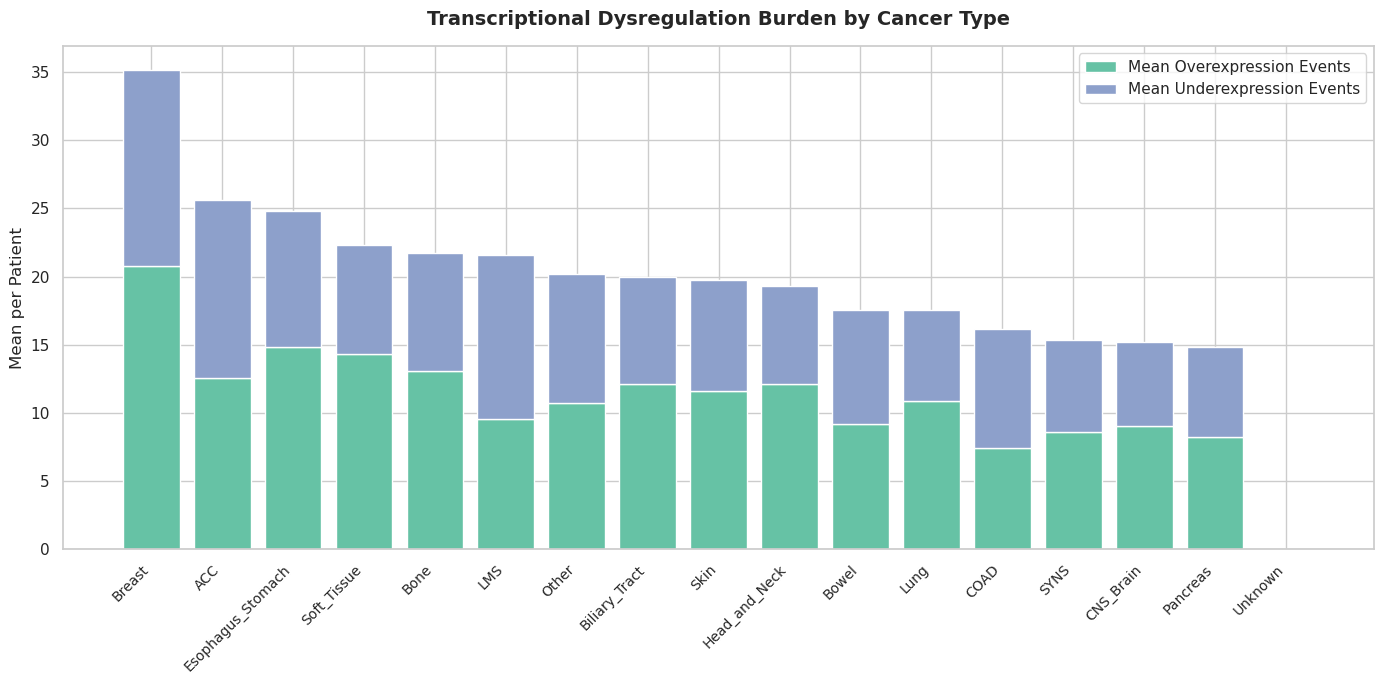

In [52]:
lineage_expr_stats = cohort.groupby('Diag').agg(
    Patient_Count=('random_id', 'count'),
    Mean_Overexp=('total_overexp_events', 'mean'),
    Mean_Underexp=('total_underexp_events', 'mean')
).reset_index()

MIN_PATIENTS = 15
lineage_expr_stats = lineage_expr_stats[lineage_expr_stats['Patient_Count'] >= MIN_PATIENTS]

lineage_expr_stats['Total_Dysregulation'] = lineage_expr_stats['Mean_Overexp'] + lineage_expr_stats['Mean_Underexp']
lineage_expr_stats = lineage_expr_stats.sort_values(by='Total_Dysregulation', ascending=False)

plt.figure(figsize=(14, 7))
p1 = plt.bar(lineage_expr_stats['Diag'], lineage_expr_stats['Mean_Overexp'], color=sns.color_palette('Set2')[0], label='Mean Overexpression Events')
p2 = plt.bar(lineage_expr_stats['Diag'], lineage_expr_stats['Mean_Underexp'], bottom=lineage_expr_stats['Mean_Overexp'], color=sns.color_palette('Set2')[2], label='Mean Underexpression Events')

plt.xticks(rotation=45, ha='right', fontsize=10)
plt.ylabel('Mean per Patient', fontsize=12)
plt.title('Transcriptional Dysregulation Burden by Cancer Type', fontsize=14, fontweight='bold', pad=15)
plt.legend()
plt.tight_layout()
plt.show()

In [53]:
patient_onco = outrider[['random_id', 'Oncotree Code']].drop_duplicates(subset=['random_id'])

cohort = cohort.merge(patient_onco, on='random_id', how='left')
cohort['Oncotree Code'] = cohort['Oncotree Code'].fillna('Unknown')

In [54]:
MIN_GLM_PATIENTS = 50

diag_counts = cohort['Oncotree Code'].value_counts()
stable_lineages = diag_counts[diag_counts >= MIN_GLM_PATIENTS].index.tolist()

formula_subset = (
    "outlier_count ~ core_pol2_burden + acc_pol2_burden + "
    "total_overexp_events + total_underexp_events"
)

results_list = []

for diag in stable_lineages:
    subset_data = cohort[cohort['Oncotree Code'] == diag]
    
    try:
        model_subset = smf.glm(formula=formula_subset, 
                               data=subset_data, 
                               family=sm.families.NegativeBinomial()).fit(disp=0) 
        
        pvals = model_subset.pvalues
        coefs = model_subset.params
        
        results_list.append({
            'Cancer_Type': diag,
            'N_Patients': len(subset_data),
            'Overexp_P_Value': pvals.get('total_overexp_events', np.nan),
            'Underexp_P_Value': pvals.get('total_underexp_events', np.nan),
            'Core_Pol2_P_Value': pvals.get('core_pol2_burden', np.nan),
            'Acc_Pol2_P_Value': pvals.get('acc_pol2_burden', np.nan),
            'Overexp_Coef': coefs.get('total_overexp_events', np.nan),
            'Underexp_Coef': coefs.get('total_underexp_events', np.nan)
        })
        
    except Exception as e:
        print(f"Model failed to converge for {diag}: {e}")

lineage_glm_results = pd.DataFrame(results_list)

lineage_glm_results = lineage_glm_results.sort_values(by='Overexp_P_Value')

display(lineage_glm_results)

Model failed to converge for Unknown: The first guess on the deviance function returned a nan.  This could be a boundary  problem and should be reported.


/opt/modules/i12g/anaconda/envs/cancer_env_local/lib/python3.10/site-packages/statsmodels/genmod/families/family.py:1402: RuntimeWarning: invalid value encountered in divide
  endog_mu = self._clean(endog / mu)


,Cancer_Type,N_Patients,Overexp_P_Value,Underexp_P_Value,Core_Pol2_P_Value,Acc_Pol2_P_Value,Overexp_Coef,Underexp_Coef
8,UM,59,0.003793,0.814965,0.999395,0.999348,0.154611,0.021787
2,COAD,102,0.030116,0.000005,0.999305,0.999040,0.091526,0.057825
3,SYNS,88,0.032533,0.206764,0.998466,0.998466,0.064272,0.030175
4,UNCMAL,69,0.072566,0.003870,0.999046,0.999109,-0.132743,0.082726
7,MFH,61,0.117596,0.024684,0.998648,0.225975,0.026609,0.038686
0,LMS,123,0.173972,0.837983,0.253432,0.295980,0.020987,-0.003456
16,GIST,50,0.233166,0.346022,0.994011,0.999467,0.206277,-0.905128
1,ACC,122,0.288537,0.756679,0.999193,0.998838,0.026756,-0.007297
10,SARCNOS,58,0.391824,0.219481,0.000006,0.202298,0.011258,0.021759
6,IHCH,64,0.436145,0.600675,0.998590,0.999093,0.037676,0.020304


# Week of Jul 7th
- repeat cnv plots for under/ overexpression (>= 10 outliers) + polymerase2 (has underexpression outlier in pol2gene vs not)
- look at coad (?)
- make some slides about most important findings 

In [55]:
pol2_outrider = outrider[outrider['geneID_filtered'].isin(pol2_genes_list)]

pol2_under_patients = pol2_outrider[pol2_outrider['Outlier status'] == 'Underexpression']['random_id'].unique()
pol2_over_patients = pol2_outrider[pol2_outrider['Outlier status'] == 'Overexpression']['random_id'].unique()

cohort['has_pol2_underexp'] = cohort['random_id'].isin(pol2_under_patients).astype(int)
cohort['has_pol2_overexp'] = cohort['random_id'].isin(pol2_over_patients).astype(int)

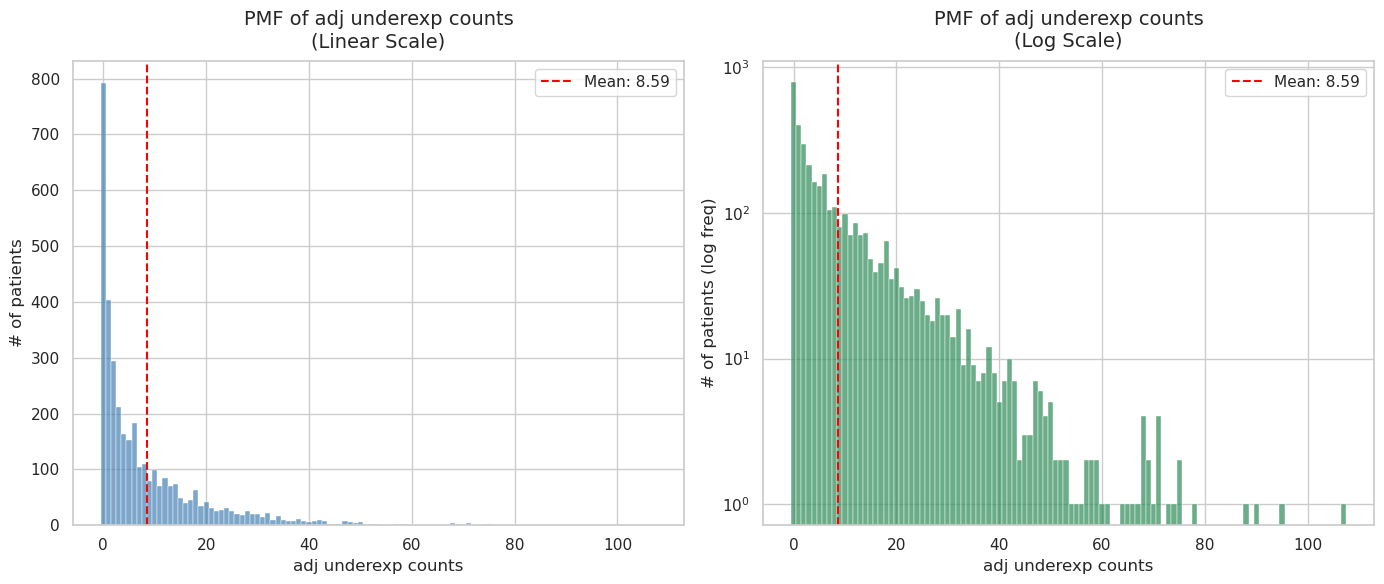

In [56]:
cohort['pol2_underexp_counts'] = outrider[
    (outrider['geneID_filtered'].isin(pol2_genes_list)) & 
    (outrider['Outlier status'] == 'Underexpression')
].groupby('random_id').size().reindex(cohort['random_id'], fill_value=0).values

cohort['adjusted_underexp_events'] = cohort['total_underexp_events'] - cohort['pol2_underexp_counts']

y_adj = cohort['adjusted_underexp_events'].values

mean_val = np.mean(y_adj)
var_val = np.var(y_adj)
pct_zeros = (np.sum(y_adj == 0) / len(y_adj)) * 100

sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sns.histplot(y_adj, discrete=True, color='steelblue', ax=axes[0], alpha=0.7)
axes[0].axvline(mean_val, color='red', linestyle='--', label=f'Mean: {mean_val:.2f}')
axes[0].set_title('PMF of adj underexp counts\n(Linear Scale)', fontsize=14, pad=10)
axes[0].set_xlabel('adj underexp counts', fontsize=12)
axes[0].set_ylabel('# of patients', fontsize=12)
axes[0].legend()

sns.histplot(y_adj, discrete=True, color='seagreen', ax=axes[1], alpha=0.7)
axes[1].set_yscale('log')
axes[1].axvline(mean_val, color='red', linestyle='--', label=f'Mean: {mean_val:.2f}')
axes[1].set_title('PMF of adj underexp counts\n(Log Scale)', fontsize=14, pad=10)
axes[1].set_xlabel('adj underexp counts', fontsize=12)
axes[1].set_ylabel('# of patients (log freq)', fontsize=12)
axes[1].legend()

plt.tight_layout()
plt.show()

adjustments based on the dispersion: 
- correction of part-whole bias (adjusted_underexp_events)
- total_cnv_genes was on different scale to pol2 indicator ("Hessian inversion failures" during MLE). covariate is standardised to cnv_zscore 
- "h3c" standard errors

In [57]:
cohort['cnv_zscore'] = (cohort['total_cnv_genes'] - cohort['total_cnv_genes'].mean()) / cohort['total_cnv_genes'].std()
formula_stable = 'adjusted_underexp_events ~ has_pol2_underexp + cnv_zscore'

model_stable = smf.glm(formula=formula_stable, 
                       data=cohort, 
                       family=sm.families.Poisson()).fit(cov_type='HC3')

print(model_stable.summary())

                    Generalized Linear Model Regression Results                     
Dep. Variable:     adjusted_underexp_events   No. Observations:                 3616
Model:                                  GLM   Df Residuals:                     3613
Model Family:                       Poisson   Df Model:                            2
Link Function:                          Log   Scale:                          1.0000
Method:                                IRLS   Log-Likelihood:                -25778.
Date:                      Wed, 15 Jul 2026   Deviance:                       41073.
Time:                              00:15:30   Pearson chi2:                 5.31e+04
No. Iterations:                           5   Pseudo R-squ. (CS):             0.6922
Covariance Type:                        HC3                                         
                        coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------

In [58]:
model_stable.pvalues

Intercept            0.000000e+00
has_pol2_underexp    3.827347e-64
cnv_zscore           6.472337e-15
dtype: float64

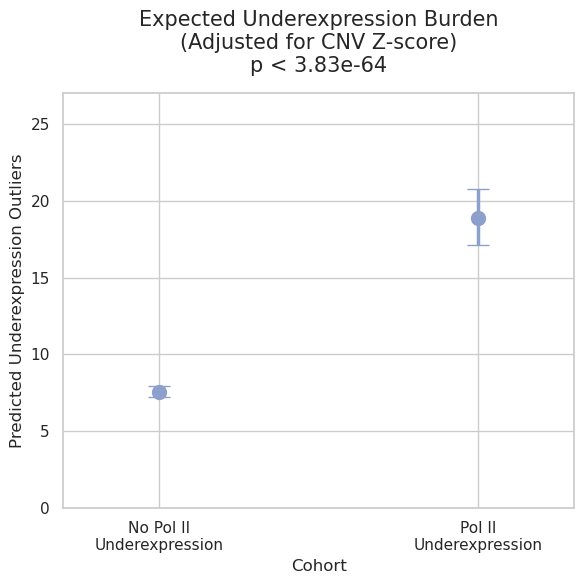

In [59]:
dummy_data = pd.DataFrame({
    'has_pol2_underexp': [0, 1],
    'cnv_zscore': [0, 0] 
})

predictions = model_stable.get_prediction(dummy_data)
summary = predictions.summary_frame()

summary['Group'] = ['No Pol II \n Underexpression', 'Pol II \n Underexpression']

x = [0, 1]
labels = ['No Pol II\nUnderexpression', 'Pol II\nUnderexpression']


plt.figure(figsize=(6, 6))
plt.errorbar(
    x=x,
    y=summary['mean'],
    yerr=[summary['mean'] - summary['mean_ci_lower'],
          summary['mean_ci_upper'] - summary['mean']],
    fmt='o',
    color=sns.color_palette("Set2")[2],
    markersize=10,
    capsize=8,
    linewidth=2.5
)

plt.xticks(x, labels)
plt.xlim(-0.3, 1.3)

plt.title(f"Expected Underexpression Burden\n(Adjusted for CNV Z-score)\np < {model_stable.pvalues['has_pol2_underexp']:.2e}", fontsize=15, pad=15)
plt.ylabel('Predicted Underexpression Outliers', fontsize=12)
plt.xlabel('Cohort', fontsize=12)
plt.ylim(0, summary['mean_ci_upper'].max() * 1.3)
plt.tight_layout()
plt.show()

/scratch/tmp/deben/ipykernel_3014242/3755727198.py:32: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  plt.xticks(ticks=[0, 1], labels=[f'No Pol II Underexpression\n(n={n_counts[0]})', f'Pol II Underexpression\n(n={n_counts[1]})'])


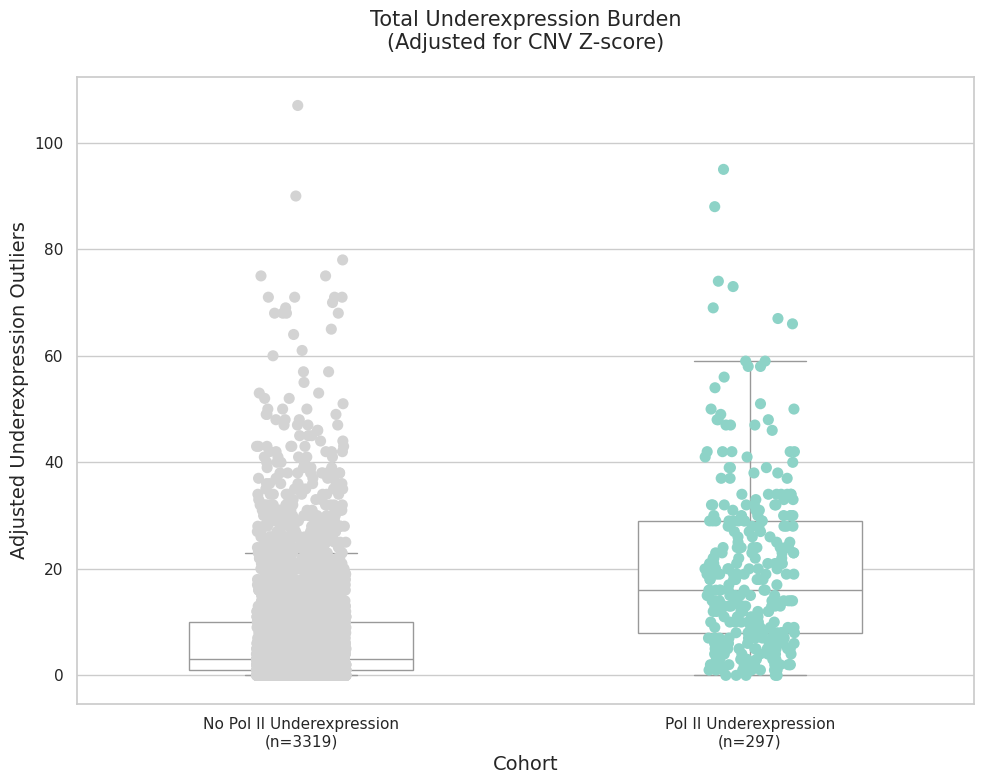

In [60]:
cohort['Cohort_Label'] = cohort['has_pol2_underexp'].map({0: 'No Pol II \n Underexpression', 1: 'Pol II \n Underexpression'})

n_counts = cohort['Cohort_Label'].value_counts()

plt.figure(figsize=(10, 8))
sns.set_theme(style="whitegrid")

ax = sns.boxplot(
    data=cohort, 
    x='Cohort_Label', 
    y='adjusted_underexp_events', 
    color='white', 
    width=0.5,           
    showfliers=False
)

sns.stripplot(
    data=cohort, 
    x='Cohort_Label', 
    y='adjusted_underexp_events', 
    hue='has_pol2_underexp',
    palette={0: '#d3d3d3', 1: '#8dd3c7'}, 
    jitter=0.1,
    size=8,
    legend=False
)

plt.title('Total Underexpression Burden\n(Adjusted for CNV Z-score)', fontsize=15, pad=20)
plt.xlabel('Cohort', fontsize=14)
plt.ylabel('Adjusted Underexpression Outliers', fontsize=14)

plt.xticks(ticks=[0, 1], labels=[f'No Pol II Underexpression\n(n={n_counts[0]})', f'Pol II Underexpression\n(n={n_counts[1]})'])

plt.tight_layout()
plt.show()

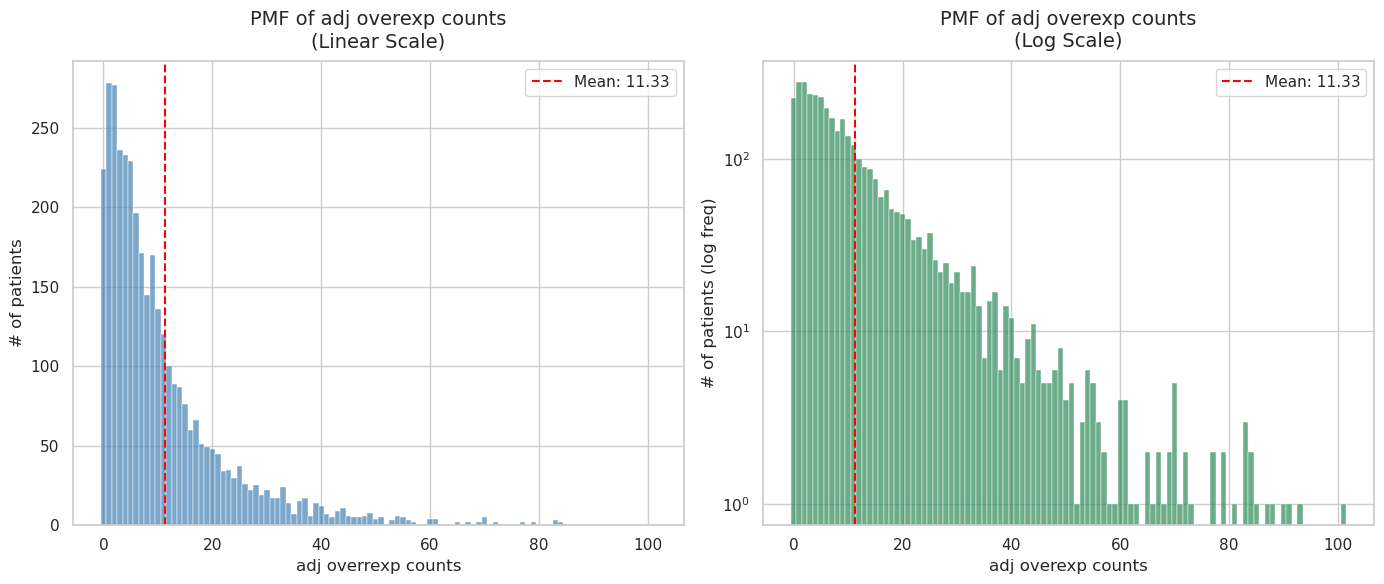

In [61]:
cohort['pol2_overexp_counts'] = outrider[
    (outrider['geneID_filtered'].isin(pol2_genes_list)) & 
    (outrider['Outlier status'] == 'Overexpression')
].groupby('random_id').size().reindex(cohort['random_id'], fill_value=0).values

cohort['adjusted_overexp_events'] = cohort['total_overexp_events'] - cohort['pol2_overexp_counts']

y_adj = cohort['adjusted_overexp_events'].values

mean_val = np.mean(y_adj)
var_val = np.var(y_adj)
pct_zeros = (np.sum(y_adj == 0) / len(y_adj)) * 100

sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sns.histplot(y_adj, discrete=True, color='steelblue', ax=axes[0], alpha=0.7)
axes[0].axvline(mean_val, color='red', linestyle='--', label=f'Mean: {mean_val:.2f}')
axes[0].set_title('PMF of adj overexp counts\n(Linear Scale)', fontsize=14, pad=10)
axes[0].set_xlabel('adj overrexp counts', fontsize=12)
axes[0].set_ylabel('# of patients', fontsize=12)
axes[0].legend()

sns.histplot(y_adj, discrete=True, color='seagreen', ax=axes[1], alpha=0.7)
axes[1].set_yscale('log')
axes[1].axvline(mean_val, color='red', linestyle='--', label=f'Mean: {mean_val:.2f}')
axes[1].set_title('PMF of adj overexp counts\n(Log Scale)', fontsize=14, pad=10)
axes[1].set_xlabel('adj overexp counts', fontsize=12)
axes[1].set_ylabel('# of patients (log freq)', fontsize=12)
axes[1].legend()

plt.tight_layout()
plt.show()

In [62]:
formula_stable_over = 'adjusted_overexp_events ~ has_pol2_overexp + cnv_zscore'

model_stable_over = smf.glm(formula=formula_stable_over, 
                       data=cohort, 
                       family=sm.families.Poisson()).fit(cov_type='HC3')

print(model_stable_over.summary())

                    Generalized Linear Model Regression Results                    
Dep. Variable:     adjusted_overexp_events   No. Observations:                 3616
Model:                                 GLM   Df Residuals:                     3613
Model Family:                      Poisson   Df Model:                            2
Link Function:                         Log   Scale:                          1.0000
Method:                               IRLS   Log-Likelihood:                -22855.
Date:                     Wed, 15 Jul 2026   Deviance:                       32543.
Time:                             00:15:31   Pearson chi2:                 3.91e+04
No. Iterations:                          5   Pseudo R-squ. (CS):             0.8872
Covariance Type:                       HC3                                         
                       coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------

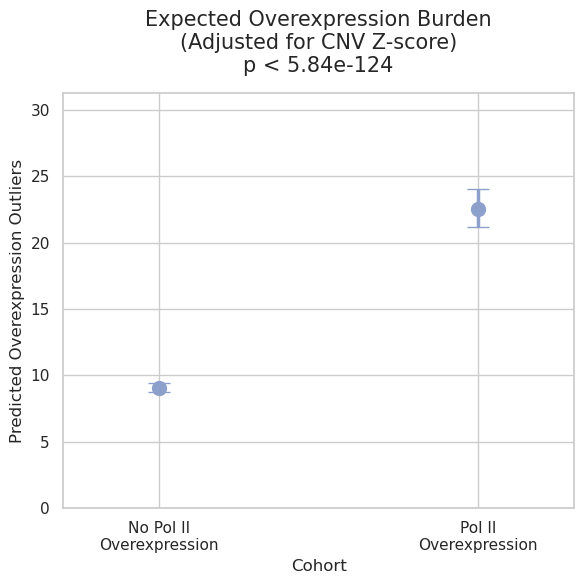

In [63]:
dummy_data_over = pd.DataFrame({
    'has_pol2_overexp': [0, 1],
    'cnv_zscore': [0, 0] 
})

predictions = model_stable_over.get_prediction(dummy_data_over)
summary = predictions.summary_frame()

summary['Group'] = ['No Pol II \n Overexpression', 'Pol II \n Overexpression']

x = [0, 1]
labels = ['No Pol II\nOverexpression', 'Pol II\nOverexpression']


plt.figure(figsize=(6, 6))
plt.errorbar(
    x=x,
    y=summary['mean'],
    yerr=[summary['mean'] - summary['mean_ci_lower'],
          summary['mean_ci_upper'] - summary['mean']],
    fmt='o',
    color=sns.color_palette("Set2")[2],
    markersize=10,
    capsize=8,
    linewidth=2.5
)

plt.xticks(x, labels)
plt.xlim(-0.3, 1.3)

plt.title(f"Expected Overexpression Burden\n(Adjusted for CNV Z-score)\np < {model_stable_over.pvalues['has_pol2_overexp']:.2e}", fontsize=15, pad=15)
plt.ylabel('Predicted Overexpression Outliers', fontsize=12)
plt.xlabel('Cohort', fontsize=12)
plt.ylim(0, summary['mean_ci_upper'].max() * 1.3)
plt.tight_layout()
plt.show()

/scratch/tmp/deben/ipykernel_3014242/936242978.py:28: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  plt.xticks(ticks=[0, 1], labels=[f'No Pol II Overexpression\n(n={n_counts[0]})', f'Pol II Overexpression\n(n={n_counts[1]})'])


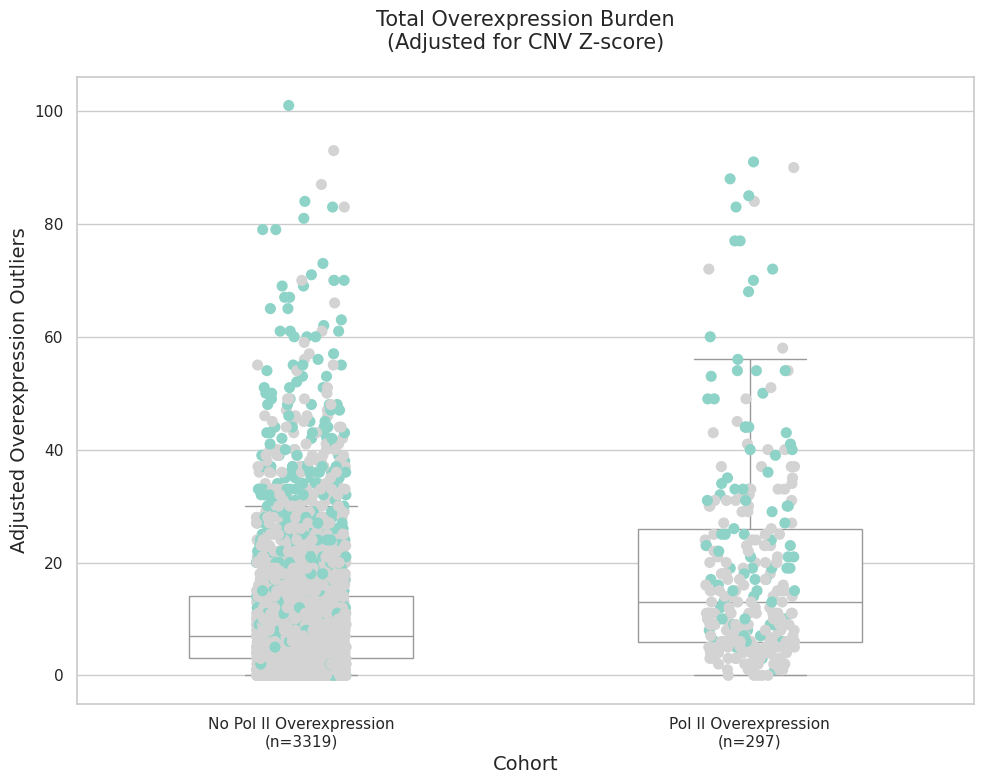

In [64]:
plt.figure(figsize=(10, 8))
sns.set_theme(style="whitegrid")

ax = sns.boxplot(
    data=cohort, 
    x='Cohort_Label', 
    y='adjusted_overexp_events', 
    color='white', 
    width=0.5,           
    showfliers=False
)

sns.stripplot(
    data=cohort, 
    x='Cohort_Label', 
    y='adjusted_overexp_events', 
    hue='has_pol2_overexp',
    palette={0: '#d3d3d3', 1: '#8dd3c7'}, 
    jitter=0.1,
    size=8,
    legend=False
)

plt.title('Total Overexpression Burden\n(Adjusted for CNV Z-score)', fontsize=15, pad=20)
plt.xlabel('Cohort', fontsize=14)
plt.ylabel('Adjusted Overexpression Outliers', fontsize=14)

plt.xticks(ticks=[0, 1], labels=[f'No Pol II Overexpression\n(n={n_counts[0]})', f'Pol II Overexpression\n(n={n_counts[1]})'])

plt.tight_layout()
plt.show()

# Week of Jul 14th
- Random background against polymerase pathway in underexpression analysis
- Have is_carrier CNV as covariate instead of zScore
- check the y-axis in boxplots, it should be total number of underexpression outliers in the sample
- Also can check wilcoxen test pvalues

/scratch/tmp/deben/ipykernel_3014242/2146743550.py:3: UserWarning: 

The `join` parameter is deprecated and will be removed in v0.15.0. You can remove the line between points with `linestyle='none'`.

  sns.pointplot(


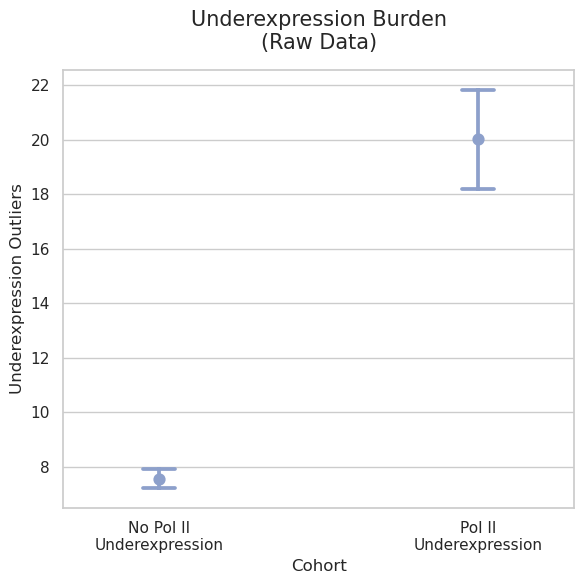

In [65]:
plt.figure(figsize=(6, 6))

sns.pointplot(
    data=cohort,
    x='has_pol2_underexp',
    y='adjusted_underexp_events',
    color=sns.color_palette("Set2")[2],
    errorbar=('ci', 95),  
    capsize=0.1,         
    join=False          
)

labels = ['No Pol II\nUnderexpression', 'Pol II\nUnderexpression']
plt.xticks(ticks=[0, 1], labels=labels)
plt.xlim(-0.3, 1.3)

plt.title("Underexpression Burden\n(Raw Data)", fontsize=15, pad=15)
plt.ylabel('Underexpression Outliers', fontsize=12)
plt.xlabel('Cohort', fontsize=12)

plt.tight_layout()
plt.show()

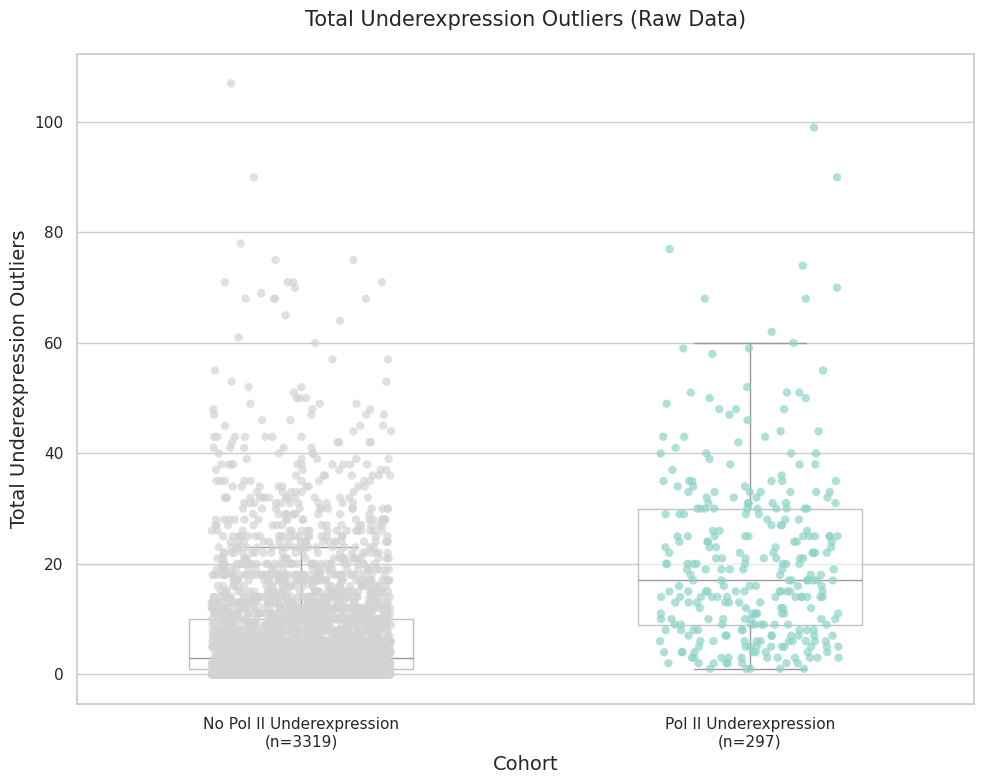

In [66]:
cohort['Cohort_Label'] = cohort['has_pol2_underexp'].map({0: 'No Pol II Underexpression', 1: 'Pol II Underexpression'})
n_counts = cohort['Cohort_Label'].value_counts()

plt.figure(figsize=(10, 8))
sns.set_theme(style="whitegrid")

ax = sns.boxplot(
    data=cohort, 
    x='has_pol2_underexp', 
    y='total_underexp_events', 
    color='white', 
    width=0.5,           
    showfliers=False,
    boxprops=dict(alpha=0.6)
)

sns.stripplot(
    data=cohort, 
    x='has_pol2_underexp', 
    y='total_underexp_events', 
    hue='has_pol2_underexp',
    palette={0: '#d3d3d3', 1: '#8dd3c7'}, 
    jitter=0.2,         
    size=6,
    alpha=0.7,
    legend=False
)

plt.title('Total Underexpression Outliers (Raw Data)', fontsize=15, pad=20)
plt.xlabel('Cohort', fontsize=14)
plt.ylabel('Total Underexpression Outliers', fontsize=14)

plt.xticks(
    ticks=[0, 1], 
    labels=[f'No Pol II Underexpression\n(n={n_counts["No Pol II Underexpression"]})', 
            f'Pol II Underexpression\n(n={n_counts["Pol II Underexpression"]})']
)

plt.tight_layout()
plt.show()

/scratch/tmp/deben/ipykernel_3014242/1153546115.py:3: UserWarning: 

The `join` parameter is deprecated and will be removed in v0.15.0. You can remove the line between points with `linestyle='none'`.

  sns.pointplot(


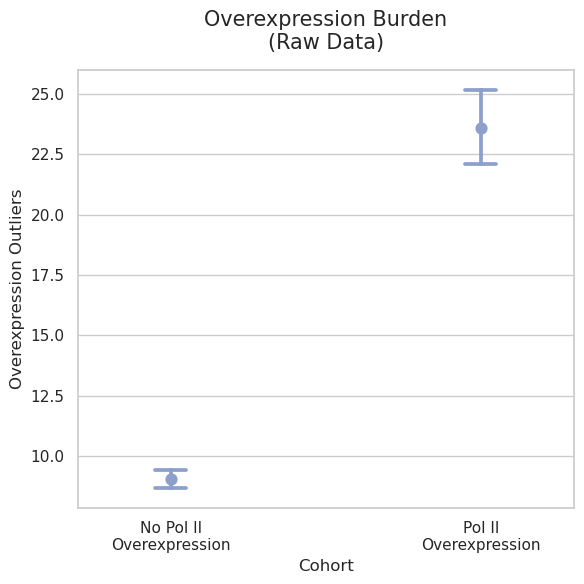

In [67]:
plt.figure(figsize=(6, 6))

sns.pointplot(
    data=cohort,
    x='has_pol2_overexp',
    y='adjusted_overexp_events',
    color=sns.color_palette("Set2")[2],
    errorbar=('ci', 95),  
    capsize=0.1,         
    join=False          
)

labels = ['No Pol II\nOverexpression', 'Pol II\nOverexpression']
plt.xticks(ticks=[0, 1], labels=labels)
plt.xlim(-0.3, 1.3)

plt.title("Overexpression Burden\n(Raw Data)", fontsize=15, pad=15)
plt.ylabel('Overexpression Outliers', fontsize=12)
plt.xlabel('Cohort', fontsize=12)

plt.tight_layout()
plt.show()

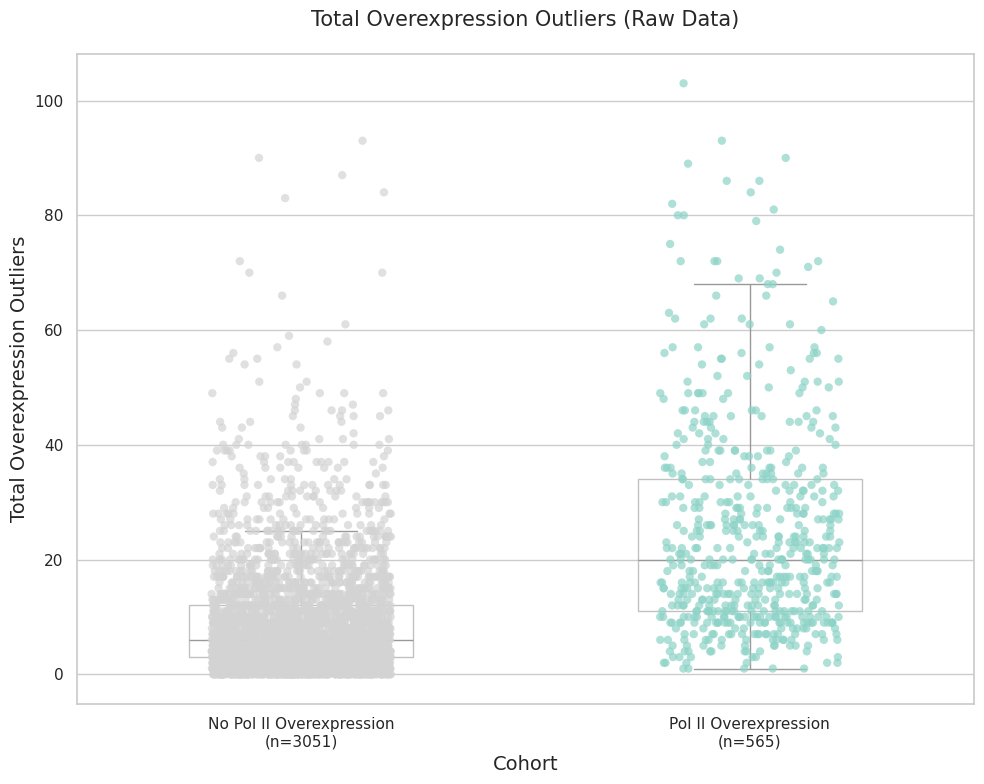

In [68]:
cohort['Cohort_Label'] = cohort['has_pol2_overexp'].map({0: 'No Pol II Overexpression', 1: 'Pol II Overexpression'})
n_counts = cohort['Cohort_Label'].value_counts()

plt.figure(figsize=(10, 8))
sns.set_theme(style="whitegrid")

ax = sns.boxplot(
    data=cohort, 
    x='has_pol2_overexp', 
    y='total_overexp_events', 
    color='white', 
    width=0.5,           
    showfliers=False,
    boxprops=dict(alpha=0.6)
)

sns.stripplot(
    data=cohort, 
    x='has_pol2_overexp', 
    y='total_overexp_events', 
    hue='has_pol2_overexp',
    palette={0: '#d3d3d3', 1: '#8dd3c7'}, 
    jitter=0.2,         
    size=6,
    alpha=0.7,
    legend=False
)

plt.title('Total Overexpression Outliers (Raw Data)', fontsize=15, pad=20)
plt.xlabel('Cohort', fontsize=14)
plt.ylabel('Total Overexpression Outliers', fontsize=14)

plt.xticks(
    ticks=[0, 1], 
    labels=[f'No Pol II Overexpression\n(n={n_counts["No Pol II Overexpression"]})', 
            f'Pol II Overexpression\n(n={n_counts["Pol II Overexpression"]})']
)

plt.tight_layout()
plt.show()

In [69]:
n_permutations = 10000
all_genes = outrider['geneID_filtered'].dropna().unique()
target_size = len(pol2_genes_list)

obs_coef = model_stable.params['has_pol2_underexp']

null_coefficients = []

np.random.seed(42) 

for i in tqdm(range(n_permutations), desc="progress"):
    random_genes_list = np.random.choice(all_genes, size=target_size, replace=False)
    
    random_outrider = outrider[(outrider['geneID_filtered'].isin(random_genes_list)) & 
                               (outrider['Outlier status'] == 'Underexpression')]
    random_under_patients = random_outrider['random_id'].unique()
    
    cohort['has_random_underexp'] = cohort['random_id'].isin(random_under_patients).astype(int)
    
    try:
        model_rand = smf.glm(formula='adjusted_underexp_events ~ has_random_underexp + cnv_zscore', 
                             data=cohort, 
                             family=sm.families.Poisson()).fit(cov_type='HC3', disp=0)
        null_coefficients.append(model_rand.params['has_random_underexp'])
    except Exception:
        null_coefficients.append(np.nan)

null_coefficients = np.array(null_coefficients)
null_coefficients = null_coefficients[~np.isnan(null_coefficients)]
n_successful = len(null_coefficients)

extreme_count = np.sum(null_coefficients >= obs_coef)
empirical_p_val = (extreme_count + 1) / (n_successful + 1)

progress:   3%|▎         | 348/10000 [00:06<03:02, 52.76it/s]

progress: 100%|██████████| 10000/10000 [03:11<00:00, 52.19it/s]


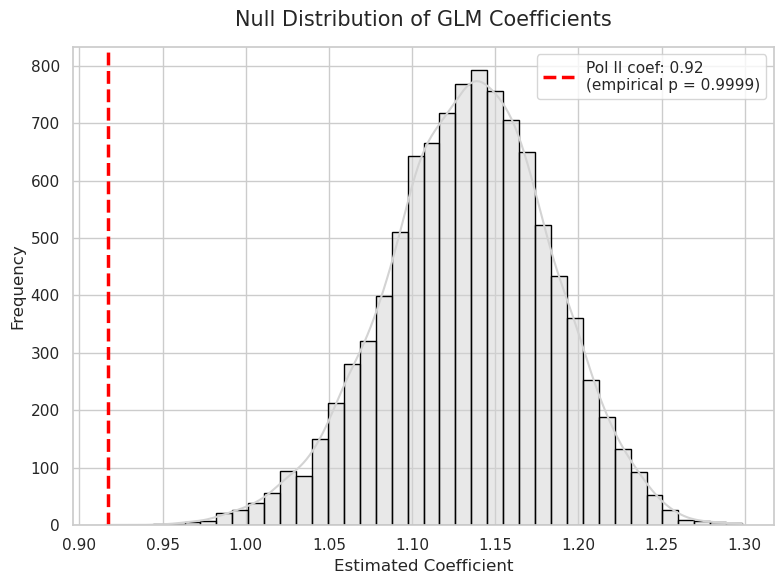

In [70]:
sns.set_theme(style="whitegrid")
plt.figure(figsize=(8, 6))

sns.histplot(null_coefficients, bins=40, color='lightgray', edgecolor='black', kde=True)
plt.axvline(obs_coef, color='red', linestyle='--', linewidth=2.5, 
            label=f'Pol II coef: {obs_coef:.2f}\n(empirical p = {empirical_p_val:.4f})')

plt.title('Null Distribution of GLM Coefficients', fontsize=15, pad=15)
plt.xlabel('Estimated Coefficient', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.legend()
plt.tight_layout()
plt.show()

In [71]:
conn = sqlite3.connect(DB_PATH)
all_pathways = pd.read_sql("SELECT DISTINCT pathway_name FROM pathways", conn)['pathway_name'].tolist() # 2267 pathways
conn.close()

In [84]:
variant_counts = res.groupby('random_id').size().reset_index(name='total_variants')
cohort = cohort.merge(variant_counts, on='random_id', how='left').fillna({'total_variants': 0})

new_formula = (
    "adjusted_underexp_events ~ has_defect + "
    "total_cnv_genes + total_variants + "
    "has_overexp_onco + has_underexp_tsg"
)

pathway_results = []

for pathway in tqdm(all_pathways, desc="progress"):
    conn = sqlite3.connect(DB_PATH)
    query = """
        SELECT symbol 
        FROM genes 
        JOIN pathways ON genes.ensembl_gene_id = pathways.ensembl_id 
        WHERE pathway_name = ?
    """
    pathway_genes = pd.read_sql(query, conn, params=(pathway,))['symbol'].unique().tolist()
    conn.close()
    
    if len(pathway_genes) < 5: 
        continue
    
    pathway_carriers = res[res['Gene'].isin(pathway_genes)]['random_id'].unique()
    cohort['has_defect'] = cohort['random_id'].isin(pathway_carriers).astype(int)
    
    try:
        model = smf.glm(formula=new_formula, 
                        data=cohort, 
                        family=sm.families.Poisson()).fit(disp=0)
        
        pathway_results.append({
            'Pathway': pathway,
            'P_Value': model.pvalues['has_defect'],
            'Coef': model.params['has_defect']
        })
    except Exception:
        continue

pathway_df = pd.DataFrame(pathway_results)

progress: 100%|██████████| 2267/2267 [06:54<00:00,  5.47it/s]


In [85]:
pvals_array = pathway_df['P_Value'].fillna(1.0).astype(float)

_, padj, _, _ = multipletests(pvals_array, method='fdr_bh')

In [86]:
pathway_df['padj'] = padj

In [87]:
print(pathway_df.sort_values('padj').head(10))

                                                Pathway        P_Value  \
1377          Formation of ATP by chemiosmotic coupling   0.000000e+00   
43    Immunoregulatory interactions between a Lympho...  6.312355e-195   
286                             Platelet degranulation   1.614954e-164   
213          Recruitment of NuMA to mitotic centrosomes  6.918738e-140   
211   Recruitment of mitotic centrosome proteins and...  3.529190e-139   
209      Regulation of PLK1 Activity at G2/M Transition  7.385586e-139   
117   MLL4 and MLL3 complexes regulate expression of...  2.737550e-134   
365          Interleukin-4 and Interleukin-13 signaling  6.072624e-134   
99                      Potential therapeutics for SARS  2.045063e-131   
212   Loss of proteins required for interphase micro...  2.213921e-130   

              Coef           padj  
1377 -1.215089e-13   0.000000e+00  
43    4.080464e-01  5.078290e-192  
286   4.037094e-01  8.661535e-162  
213   3.825473e-01  2.783062e-137  
211  

In [88]:
final_results = pathway_df[pathway_df['Coef'].abs() > 1e-5]

final_results = final_results[final_results['Coef'] > 0.10]

In [99]:
print(final_results.sort_values('padj', ascending=True).head(20))

                                               Pathway        P_Value      Coef           padj
43   Immunoregulatory interactions between a Lympho...  6.312355e-195  0.408046  5.078290e-192
286                            Platelet degranulation   1.614954e-164  0.403709  8.661535e-162
213         Recruitment of NuMA to mitotic centrosomes  6.918738e-140  0.382547  2.783062e-137
211  Recruitment of mitotic centrosome proteins and...  3.529190e-139  0.378822  1.135693e-136
209     Regulation of PLK1 Activity at G2/M Transition  7.385586e-139  0.384291  1.980568e-136
117  MLL4 and MLL3 complexes regulate expression of...  2.737550e-134  0.361575  6.292455e-132
365         Interleukin-4 and Interleukin-13 signaling  6.072624e-134  0.349198  1.221356e-131
99                     Potential therapeutics for SARS  2.045063e-131  0.338161  3.656119e-129
212  Loss of proteins required for interphase micro...  2.213921e-130  0.385084  3.238363e-128
210               Loss of Nlp from mitotic centros

In [109]:
MAX_CARRIER_FREQ = 0.15 
JACCARD_DISTANCE_THRESHOLD = 0.5  
total_patients = len(cohort['random_id'].unique())
max_carriers_allowed = total_patients * MAX_CARRIER_FREQ
cohort['total_cnv_genes_z'] = (cohort['total_cnv_genes'] - cohort['total_cnv_genes'].mean()) / cohort['total_cnv_genes'].std()
cohort['total_variants_z'] = (cohort['total_variants'] - cohort['total_variants'].mean()) / cohort['total_variants'].std()

new_formula = (
    "adjusted_underexp_events ~ has_defect + "
    "total_cnv_genes_z + total_variants_z + "
    "has_overexp_onco + has_underexp_tsg"
)

pathway_results = []
pathway_gene_map = {}

for pathway in tqdm(all_pathways, desc="progress"):
    conn = sqlite3.connect(DB_PATH)
    query = """
        SELECT symbol 
        FROM genes 
        JOIN pathways ON genes.ensembl_gene_id = pathways.ensembl_id 
        WHERE pathway_name = ?
    """
    pathway_genes = pd.read_sql(query, conn, params=(pathway,))['symbol'].unique().tolist()
    conn.close()
    
    if len(pathway_genes) < 5 or len(pathway_genes) > 200: 
        continue
        
    pathway_carriers = res[res['Gene'].isin(pathway_genes)]['random_id'].unique()
    
    if len(pathway_carriers) > max_carriers_allowed:
        continue
        
    pathway_gene_map[pathway] = set(pathway_genes)
    cohort['has_defect'] = cohort['random_id'].isin(pathway_carriers).astype(int)
    
    try:
        model = smf.glm(formula=new_formula, 
                    data=cohort, 
                    family=sm.families.NegativeBinomial()).fit()
        
        pathway_results.append({
            'Pathway': pathway,
            'P_Value': model.pvalues['has_defect'],
            'Coef': model.params['has_defect']
        })
    except Exception as e:
        print(f"GLM Failed for pathway '{pathway}'. Error: {e}")

progress: 100%|██████████| 2267/2267 [06:53<00:00,  5.48it/s]


In [110]:
pathway_df = pd.DataFrame(pathway_results)
pvals_array = pathway_df['P_Value'].fillna(1.0).astype(float)
_, padj, _, _ = multipletests(pvals_array, method='fdr_bh')
pathway_df['padj'] = padj

sig_pathways = pathway_df[(pathway_df['padj'] < 0.05) & (pathway_df['Coef'] > 0.10)].copy()

In [111]:
if len(sig_pathways) > 1:
    top_pathway_names = sig_pathways['Pathway'].tolist()
    
    def jaccard_dist(u, v):
        i, j = int(u[0]), int(v[0])
        set_a = pathway_gene_map[top_pathway_names[i]]
        set_b = pathway_gene_map[top_pathway_names[j]]
        intersection = len(set_a.intersection(set_b))
        union = len(set_a.union(set_b))
        return 1.0 - (intersection / union if union > 0 else 0)

    indices = np.arange(len(top_pathway_names), dtype=float)[:, None]
    
    distance_matrix = pdist(indices, metric=jaccard_dist)
    Z = linkage(distance_matrix, method='average')
    
    cluster_labels = fcluster(Z, t=JACCARD_DISTANCE_THRESHOLD, criterion='distance')
    sig_pathways['Cluster'] = cluster_labels
    
    independent_nodes = sig_pathways.loc[sig_pathways.groupby('Cluster')['Coef'].idxmax()]
    independent_nodes = independent_nodes.sort_values('padj')

else:
    independent_nodes = sig_pathways

In [112]:
print(independent_nodes.head(20))

                                                Pathway       P_Value      Coef      padj  Cluster
9     EGR2 and SOX10-mediated initiation of Schwann ...  7.460686e-09  0.371734  0.000008       23
103       Norepinephrine Neurotransmitter Release Cycle  5.085708e-08  0.363522  0.000013       47
983                                           Pexophagy  2.698531e-08  0.439972  0.000013      100
1016  Classical antibody-mediated complement activation  1.598368e-07  0.306531  0.000024       83
401                       Induction of Cell-Cell Fusion  5.146808e-07  0.356190  0.000067      117
922      Drug-mediated inhibition of CDK4/CDK6 activity  1.008744e-06  0.318582  0.000116       59
858                           PTK6 Regulates Cell Cycle  3.017778e-06  0.288099  0.000313       58
552                 Transcriptional regulation by RUNX2  2.280997e-05  0.268421  0.002148       60
97                      Zygotic genome activation (ZGA)  2.953329e-05  0.296497  0.002550       25
352       

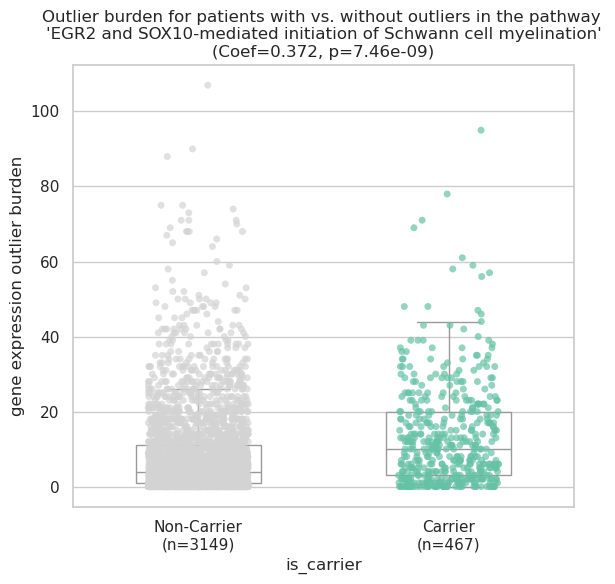

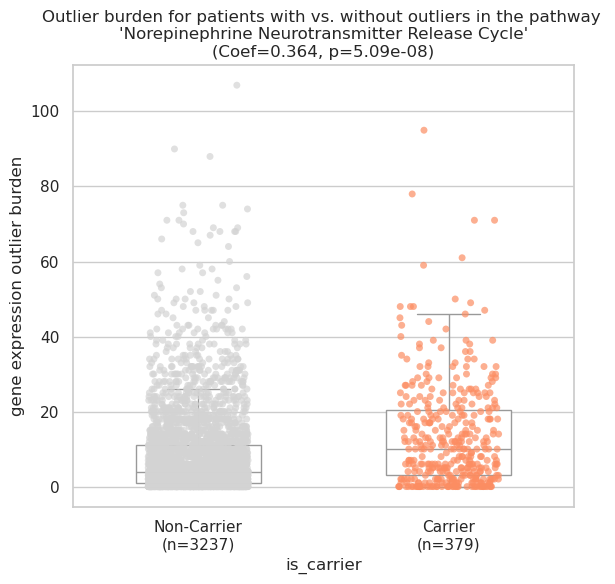

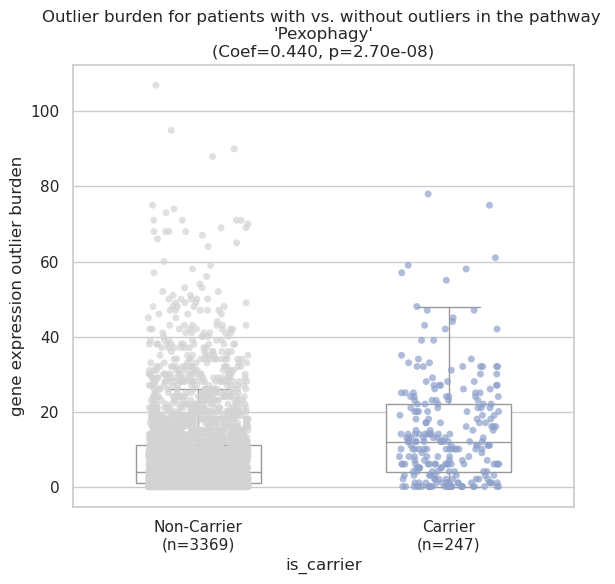

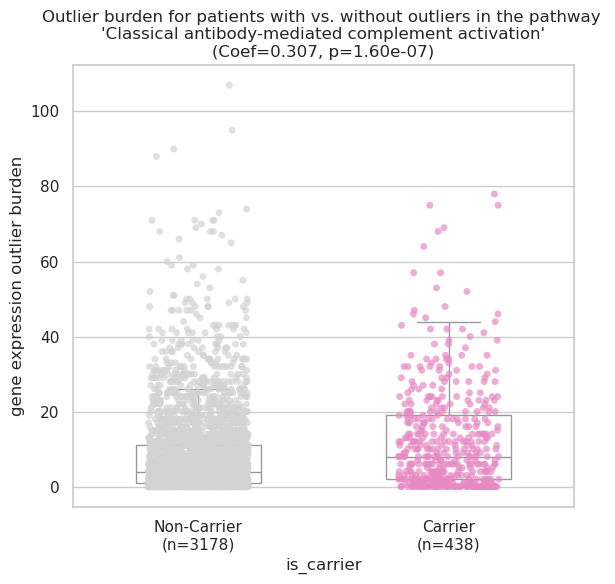

In [125]:
top_n = 4
top_pathways = independent_nodes.sort_values('padj').head(top_n)['Pathway'].tolist()
set2_palette = sns.color_palette("Set2", n_colors=top_n)

for i, pathway in enumerate(top_pathways):
    conn = sqlite3.connect(DB_PATH)
    query = f"SELECT symbol FROM genes JOIN pathways ON genes.ensembl_gene_id = pathways.ensembl_id WHERE pathway_name = '{pathway}'"
    pathway_genes = pd.read_sql(query, conn)['symbol'].unique()
    conn.close()
    
    cohort['is_carrier'] = cohort['random_id'].isin(res[res['Gene'].isin(pathway_genes)]['random_id'].unique()).astype(int)
    
    counts = cohort['is_carrier'].value_counts()
    n_non_carrier = counts.get(0, 0)
    n_carrier = counts.get(1, 0)
    
    pathway_palette = ['lightgrey', set2_palette[i]]
    
    plt.figure(figsize=(6, 6))
    
    sns.boxplot(data=cohort, x='is_carrier', y='adjusted_underexp_events', 
                color='white', width=0.5, showfliers=False)
    
    sns.stripplot(data=cohort, x='is_carrier', y='adjusted_underexp_events', 
                  hue='is_carrier', palette=pathway_palette, 
                  jitter=0.2, size=5, alpha=0.7, legend=False)
    
    p_val = independent_nodes.loc[independent_nodes['Pathway'] == pathway, 'P_Value'].values[0]
    coef = independent_nodes.loc[independent_nodes['Pathway'] == pathway, 'Coef'].values[0]
    
    plt.title(f"Outlier burden for patients with vs. without outliers in the pathway \n'{pathway}'\n(Coef={coef:.3f}, p={p_val:.2e})", fontsize=12)
    
    plt.xticks([0, 1], [f'Non-Carrier\n(n={n_non_carrier})', f'Carrier\n(n={n_carrier})'])
    plt.ylabel("gene expression outlier burden")
    plt.tight_layout()
    plt.show()